### [XGBoost in Action: A Real Dataset Walkthrough](https://pub.towardsai.net/xgboost-in-action-a-real-dataset-walkthrough-that-shows-how-everything-works-from-raw-data-to-a08422d74551)

> Shows How Everything Works (From Raw Data to SHAP Interpretability)

In [1]:
!pip install --quiet optuna optuna-dashboard shap kaggle kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 4.1 MB/s eta 0:00:00


In [2]:
import os, sys
if "google.colab" in sys.modules:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [3]:
!kaggle competitions download -c house-prices-advanced-regression-techniques -p .
!unzip -q house-prices-advanced-regression-techniques.zip && rm -f house-prices-advanced-regression-techniques.zip

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 391MB/s]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import optuna

import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score

import shap

np.set_printoptions(suppress=True, precision=5)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 14
plt.rcParams["axes.grid"] = False

import warnings
warnings.filterwarnings('ignore')

In [5]:
default_data_path = "/kaggle/input/house-prices-advanced-regression-techniques/train.csv"
train_df = pd.read_csv("/content/train.csv")     # Download from Kaggle and place here
print("Shape: ", train_df.shape)
display(train_df.head())

Shape:  (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.0000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.0000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.0000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.0000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.0000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
TARGET = "SalePrice"
train_df[TARGET] = np.log1p(train_df[TARGET])
train_df[TARGET]

,SalePrice
0,12.2477
1,12.1090
2,12.3172
3,11.8494
4,12.4292
...,...
1455,12.0725
1456,12.2549
1457,12.4931
1458,11.8645


In [7]:
X = train_df.drop(columns=["SalePrice", "Id"])
y = train_df[TARGET]
print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (1460, 79)
y shape:  (1460,)


In [8]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Numerical Columns: ", num_cols)
print("Categorical Columns: ", cat_cols)

Numerical Columns:  ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical Columns:  ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType'

In [9]:
ONE_HOT_THRESH = 10
low_card = [c for c in cat_cols if X[c].nunique(dropna=False) <= ONE_HOT_THRESH]
high_card = [c for c in cat_cols if X[c].nunique(dropna=False) > ONE_HOT_THRESH]

# Frequency encode high-cardinality
for col in high_card:
    freq = X[col].fillna("Missing").value_counts(normalize=True)
    X[col] = X[col].fillna("Missing").map(freq)

# One-hot encode low-cardinality
X[low_card] = X[low_card].fillna("Missing")
X = pd.get_dummies(X, columns=low_card, drop_first=True)

# Numeric fill
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
display(X)

,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,Exterior2nd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Missing,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,MasVnrType_BrkFace,MasVnrType_Missing,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_Missing,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Missing,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Missing,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Missing,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Missing,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Missing,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Missing,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_Missing,GarageFinish_Missing,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Missing,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Missing,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,PoolQC_Missing,Fence_GdWo,Fence_Missing,Fence_MnPrv,Fence_MnWw,MiscFeature_Missing,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0000,8450,0.1027,7,5,2003,2003,0.3527,0.3452,196.0000,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,"2,003.0000",2,548,0,61,0,0,0,0,0,2,2008,False,False,True,False,True,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,Fa

In [10]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.15, random_state=42
)

print("X_train shape: ", X_train.shape)
print("X_holdout shape: ", X_holdout.shape)
print("y_train shape: ", y_train.shape)
print("y_holdout shape: ", y_holdout.shape)

X_train shape:  (1241, 210)
X_holdout shape:  (219, 210)
y_train shape:  (1241,)
y_holdout shape:  (219,)


In [11]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_holdout)
rf_rmse = np.sqrt(mean_squared_error(y_holdout, rf_preds))
score = rf.score(X_holdout, y_holdout)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest Score:", score)

Random Forest RMSE: 0.149482253995127
Random Forest Score: 0.8827399004522308


In [12]:
dtrain = xgb.DMatrix(X_train, y_train)
dvalid = xgb.DMatrix(X_holdout, y_holdout)

base_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "seed": 42,
}

baseline = xgb.train(
    base_params,
    dtrain,
    num_boost_round=200,
    evals=[(dvalid, "validation")],
    early_stopping_rounds=20,
    verbose_eval=False
)

preds = baseline.predict(dvalid)
baseline_rmse = np.sqrt(mean_squared_error(y_holdout, preds))
print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 0.1504259061576536


In [13]:
params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42,
}

simple = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dvalid, "validation")],
    early_stopping_rounds=50,
    verbose_eval=False
)

preds = simple.predict(dvalid)
simple_rmse = np.sqrt(mean_squared_error(y_holdout, preds))
print("Simple Model RMSE:", simple_rmse)

Simple Model RMSE: 0.143314511239972


In [14]:
def objective(trial):
    param = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "seed": 42,
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_uniform("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_uniform("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0),
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, val_idx in kf.split(X_train):
        dtr = xgb.DMatrix(X_train.iloc[train_idx], y_train.iloc[train_idx])
        dva = xgb.DMatrix(X_train.iloc[val_idx], y_train.iloc[val_idx])

        bst = xgb.train(
            param,
            dtr,
            num_boost_round=2000,
            evals=[(dva, "validation")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        preds = bst.predict(dva)
        rmse_scores.append(
            np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds))
        )

    return np.mean(rmse_scores)

In [15]:
study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=40)

best_params = study.best_params
best_params

[I 2026-02-01 11:37:47,249] A new study created in memory with name: no-name-86e03287-6ea8-4f6c-b538-42b0991f533b
[I 2026-02-01 11:37:57,286] Trial 0 finished with value: 0.157743152869153 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.157743152869153.
[I 2026-02-01 11:37:58,506] Trial 1 finished with value: 0.16776077987147534 and parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 0 with value: 0.157743152869153.
[I 2026-02-01 11:38:03,562] Trial 2 finished with value: 0.1537757591810197 and parameters: {'learn

{'learning_rate': 0.04146796204479168,
 'max_depth': 10,
 'min_child_weight': 8,
 'subsample': 0.8470599717751742,
 'colsample_bytree': 0.9116131329133695,
 'gamma': 0.0038369408102562896,
 'reg_alpha': 0.3497748245532436,
 'reg_lambda': 0.8967721256572904}

In [16]:
final = xgb.train(
    best_params,
    xgb.DMatrix(X_train, y_train),
    num_boost_round=5000,
    evals=[(xgb.DMatrix(X_holdout, y_holdout), "validation")],
    early_stopping_rounds=100,
    verbose_eval=50
)

final_preds = final.predict(xgb.DMatrix(X_holdout))
final_rmse = np.sqrt(mean_squared_error(y_holdout, final_preds))
print("Final RMSE:", final_rmse)

[0]	validation-rmse:0.42340
[50]	validation-rmse:0.16982
[100]	validation-rmse:0.14620
[150]	validation-rmse:0.14163
[200]	validation-rmse:0.14090
[250]	validation-rmse:0.14068
[300]	validation-rmse:0.14060
[350]	validation-rmse:0.14060
[400]	validation-rmse:0.14041
[450]	validation-rmse:0.14041
[500]	validation-rmse:0.14037
[550]	validation-rmse:0.14036
[600]	validation-rmse:0.14032
[650]	validation-rmse:0.14032
[700]	validation-rmse:0.14025
[750]	validation-rmse:0.14021
[800]	validation-rmse:0.14022
[850]	validation-rmse:0.14021
[900]	validation-rmse:0.14021
[950]	validation-rmse:0.14019
[1000]	validation-rmse:0.14007
[1050]	validation-rmse:0.14003
[1100]	validation-rmse:0.14001
[1150]	validation-rmse:0.13998
[1200]	validation-rmse:0.13997
[1250]	validation-rmse:0.13997
[1272]	validation-rmse:0.13997
Final RMSE: 0.13996544811516093


In [17]:
importance = final.get_score(importance_type="gain")
importance_df = (
    pd.DataFrame.from_dict(importance, orient="index", columns=["gain"])
    .sort_values("gain", ascending=False)
)
display(importance_df.head(10))

,gain
OverallQual,5.4309
GarageCars,1.5029
FireplaceQu_Missing,1.1728
Fireplaces,0.4093
GrLivArea,0.4088
ExterQual_TA,0.3869
KitchenAbvGr,0.3500
CentralAir_Y,0.3423
YearBuilt,0.3060
GarageQual_TA,0.2300


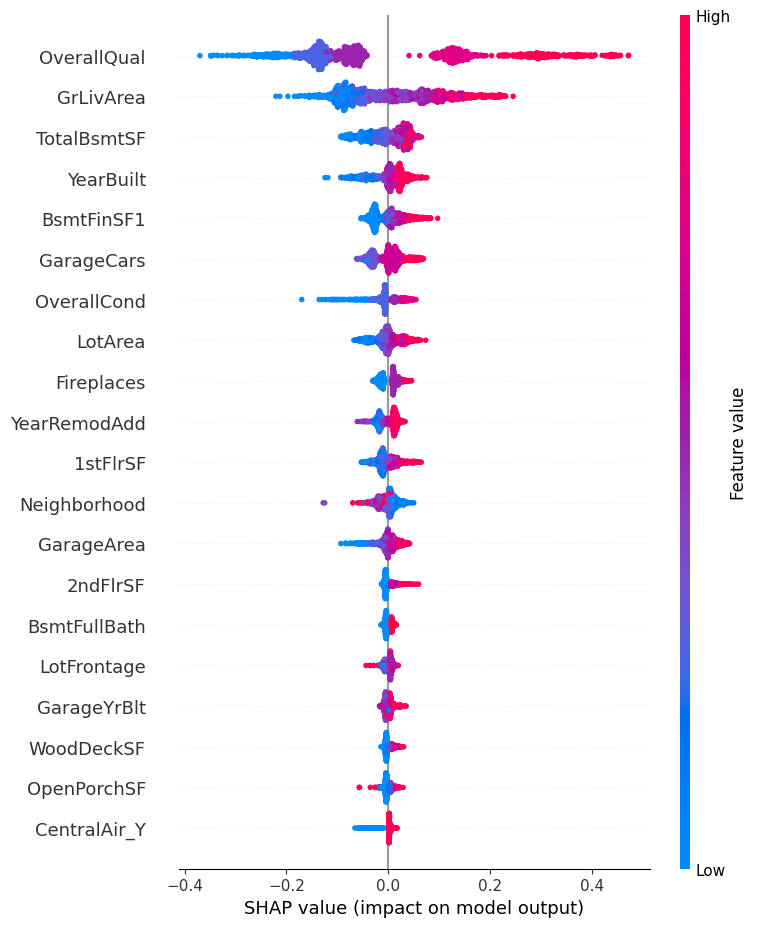

In [18]:
shap.initjs()

explainer = shap.TreeExplainer(final)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

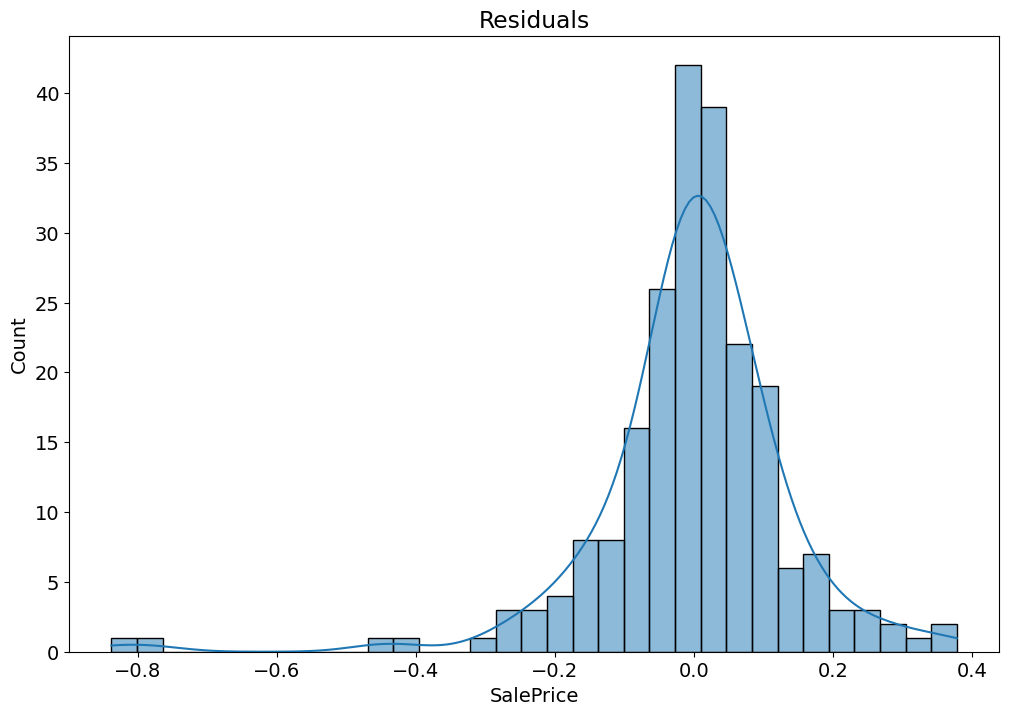

In [19]:
residuals = y_holdout - final_preds
sns.histplot(residuals, kde=True)
plt.title("Residuals")
if "google.colab" not in sys.modules:
  plt.savefig("residuals.png", bbox_inches="tight", dpi=300)
plt.show()

In [20]:
error_df = pd.DataFrame({
    "true": y_holdout,
    "pred": final_preds,
    "resid": residuals
})

error_df["abs_resid"] = error_df["resid"].abs()
error_df.sort_values("abs_resid", ascending=False).head(10)
display(error_df)

,true,pred,resid,abs_resid
892,11.9480,11.8610,0.0869,0.0869
1105,12.6916,12.7000,-0.0085,0.0085
413,11.6527,11.6095,0.0432,0.0432
522,11.9767,11.9891,-0.0125,0.0125
1036,12.6619,12.6645,-0.0026,0.0026
...,...,...,...,...
271,12.3946,12.1782,0.2165,0.2165
240,12.4780,12.5174,-0.0394,0.0394
597,12.1767,12.0862,0.0904,0.0904
946,11.8706,11.8842,-0.0136,0.0136
